# 1 - Bibliotecas Utilizadas

In [17]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

from imblearn.over_sampling import SMOTE


# Ignorar Avisos
import warnings
warnings.filterwarnings('ignore')

# 2 - Carregamento dos dados

In [5]:
pasta_atual = Path().resolve()
pasta_gold = pasta_atual.parent / 'data' / '3_gold'
pasta_gold.mkdir(parents=True, exist_ok=True)

caminho_gold = pasta_gold / 'manutencao_preditiva-gold.csv'

dados = pd.read_csv(caminho_gold)

df = dados.copy()

df.head()

,udi,tipo,torque_nm,desgaste_ferramenta_min,falha_maquina,delta_temperatura
0,1,2,42.8,0,0,-10.5
1,2,1,46.3,3,0,-10.5
2,3,1,49.4,5,0,-10.4
3,5,1,40.0,9,0,-10.5
4,6,2,41.9,11,0,-10.5


# 3 - Separação, Limpeza e Balanceamento 

In [10]:
# Separação de X e y e Removendo 'udi' 
# Garantido a proporção de 3% de falhas no treino e no teste com stratfy
X_train, X_test, y_train, y_test = train_test_split(
    df.drop(columns=['udi', 'falha_maquina']), 
    df['falha_maquina'], 
    test_size=0.2, 
    stratify=df['falha_maquina'], 
    random_state=42
)

# 2. Balanceamento com SMOTE no treino para evitar Data Leakage
X_train_sm, y_train_sm = SMOTE(random_state=42).fit_resample(X_train, y_train)

print(f"Distribuição após SMOTE no treino:\n{y_train_sm.value_counts()}")

Distribuição após SMOTE no treino:
falha_maquina
0    7342
1    7342
Name: count, dtype: int64


# 4 - Escalonamento

In [15]:
cols_continuas = ['torque_nm', 'desgaste_ferramenta_min', 'delta_temperatura']

# Criando cópias independentes para cada modelo
X_train_knn, X_test_knn = X_train_sm.copy(), X_test.copy()
X_train_tree, X_test_tree = X_train_sm.copy(), X_test.copy()

# Aplicando StandardScaler apenas nas contínuas do KNN
scaler = StandardScaler()
X_train_knn[cols_continuas] = scaler.fit_transform(X_train_knn[cols_continuas])
X_test_knn[cols_continuas] = scaler.transform(X_test_knn[cols_continuas])

Os dados da Árvore de Decisão (X_train_tree e X_test_tree) não sofreram escalonamento porque algoritmos baseados em árvores particionam os dados usando regras lógicas de desigualdade baseadas no Ganho de Informação. Eles não calculam distâncias espaciais entre os pontos, sendo imunes à escala dos atributos.

In [27]:
print("--- Análise de Overfitting: KNN ---")
for k in [3, 4, 5, 6, 7, 8, 9, 10]:
    # Instancia, treina e prevê em linhas enxutas
    knn = KNeighborsClassifier(n_neighbors=k).fit(X_train_knn, y_train_sm)
    acc_treino = accuracy_score(y_train_sm, knn.predict(X_train_knn))
    acc_teste = accuracy_score(y_test, knn.predict(X_test_knn))
    print(f"K={k} | Treino: {acc_treino:.4f} | Teste: {acc_teste:.4f}")

print("\n--- Análise de Overfitting: Árvore de Decisão ---")
for depth in [3, 4,5,6,7, 8,9,10,11, None]:
    tree = DecisionTreeClassifier(max_depth=depth, random_state=42).fit(X_train_tree, y_train_sm)
    acc_treino = accuracy_score(y_train_sm, tree.predict(X_train_tree))
    acc_teste = accuracy_score(y_test, tree.predict(X_test_tree))
    print(f"Profundidade={depth} | Treino: {acc_treino:.4f} | Teste: {acc_teste:.4f}")

# DICA PARA O SEU TEXTO: Ao rodar isso, observe a profundidade 'None'. 
# A acurácia de treino baterá 1.00 (100%), mas a de teste cairá. Isso é a prova matemática do overfitting.

--- Análise de Overfitting: KNN ---
K=3 | Treino: 0.9721 | Teste: 0.9158
K=4 | Treino: 0.9705 | Teste: 0.9279
K=5 | Treino: 0.9626 | Teste: 0.9137
K=6 | Treino: 0.9630 | Teste: 0.9216
K=7 | Treino: 0.9570 | Teste: 0.9132
K=8 | Treino: 0.9572 | Teste: 0.9221
K=9 | Treino: 0.9517 | Teste: 0.9111
K=10 | Treino: 0.9529 | Teste: 0.9163

--- Análise de Overfitting: Árvore de Decisão ---
Profundidade=3 | Treino: 0.8568 | Teste: 0.8674
Profundidade=4 | Treino: 0.8925 | Teste: 0.8205
Profundidade=5 | Treino: 0.9343 | Teste: 0.9189
Profundidade=6 | Treino: 0.9405 | Teste: 0.9168
Profundidade=7 | Treino: 0.9466 | Teste: 0.9289
Profundidade=8 | Treino: 0.9546 | Teste: 0.9242
Profundidade=9 | Treino: 0.9606 | Teste: 0.9321
Profundidade=10 | Treino: 0.9651 | Teste: 0.9242
Profundidade=11 | Treino: 0.9729 | Teste: 0.9221
Profundidade=None | Treino: 1.0000 | Teste: 0.9463


=============== RESULTADOS FINAIS ===============
Acurácia Final KNN (Teste): 0.9221
Acurácia Final Árvore (Teste): 0.9321

--- Relatório KNN ---
              precision    recall  f1-score   support

           0       0.99      0.93      0.96      1836
           1       0.27      0.77      0.40        64

    accuracy                           0.92      1900
   macro avg       0.63      0.85      0.68      1900
weighted avg       0.97      0.92      0.94      1900


--- Relatório Árvore ---
              precision    recall  f1-score   support

           0       0.99      0.94      0.96      1836
           1       0.30      0.75      0.43        64

    accuracy                           0.93      1900
   macro avg       0.64      0.84      0.70      1900
weighted avg       0.97      0.93      0.95      1900



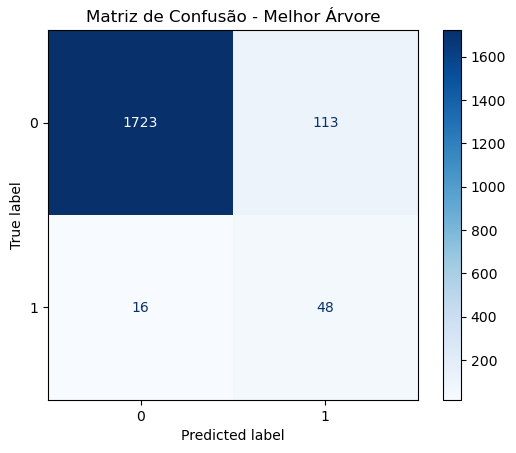

In [25]:
# Treinando os modelos campeões com as configurações mais estáveis
melhor_knn = KNeighborsClassifier(n_neighbors=8).fit(X_train_knn, y_train_sm)
melhor_arvore = DecisionTreeClassifier(max_depth=9, random_state=42).fit(X_train_tree, y_train_sm)

print("=============== RESULTADOS FINAIS ===============")
print(f"Acurácia Final KNN (Teste): {accuracy_score(y_test, melhor_knn.predict(X_test_knn)):.4f}")
print(f"Acurácia Final Árvore (Teste): {accuracy_score(y_test, melhor_arvore.predict(X_test_tree)):.4f}")

print("\n--- Relatório KNN ---")
print(classification_report(y_test, melhor_knn.predict(X_test_knn)))

print("\n--- Relatório Árvore ---")
print(classification_report(y_test, melhor_arvore.predict(X_test_tree)))

# Bônus visual: Plota a Matriz de Confusão da Árvore (geralmente a campeã em negócios industriais)
ConfusionMatrixDisplay.from_estimator(melhor_arvore, X_test_tree, y_test, cmap='Blues')
plt.title("Matriz de Confusão - Melhor Árvore")
plt.show()

=============== RESULTADOS FINAIS ===============
Acurácia Final KNN (Teste): 0.9221
Acurácia Final Árvore (Teste): 0.9321

--- Relatório KNN ---
              precision    recall  f1-score   support

           0       0.99      0.93      0.96      1836
           1       0.27      0.77      0.40        64

    accuracy                           0.92      1900
   macro avg       0.63      0.85      0.68      1900
weighted avg       0.97      0.92      0.94      1900


--- Relatório Árvore ---
              precision    recall  f1-score   support

           0       0.99      0.94      0.96      1836
           1       0.30      0.75      0.43        64

    accuracy                           0.93      1900
   macro avg       0.64      0.84      0.70      1900
weighted avg       0.97      0.93      0.95      1900



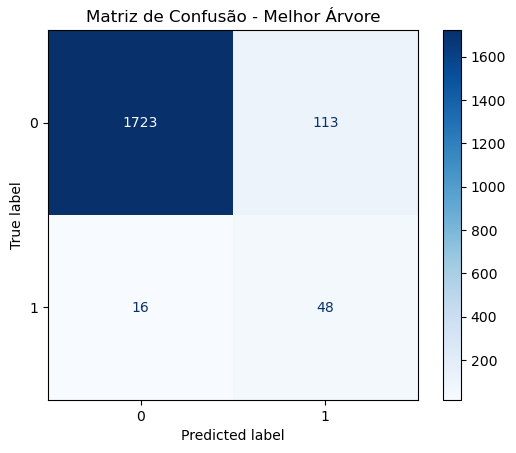


=============== IMPORTÂNCIA DAS VARIÁVEIS (ÁRVORE) ===============


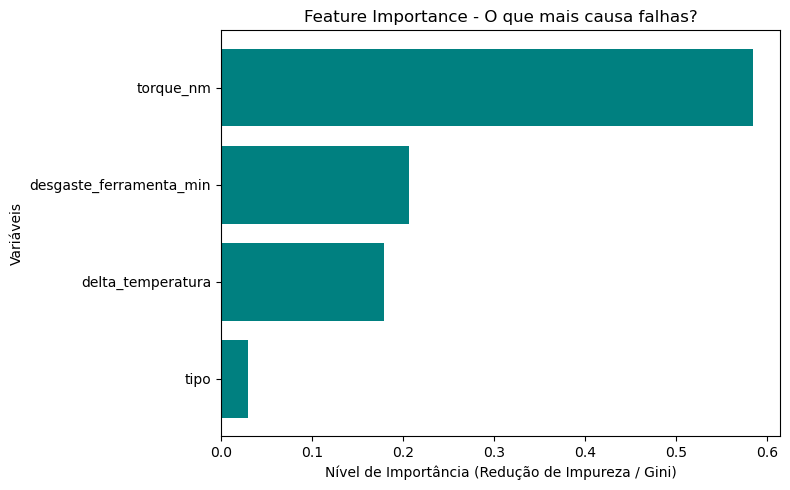

                Feature  Importancia
              torque_nm     0.584625
desgaste_ferramenta_min     0.206416
      delta_temperatura     0.179288
                   tipo     0.029672


In [28]:
# Treinando os modelos campeões com as configurações mais estáveis
melhor_knn = KNeighborsClassifier(n_neighbors=8).fit(X_train_knn, y_train_sm)
melhor_arvore = DecisionTreeClassifier(max_depth=9, random_state=42).fit(X_train_tree, y_train_sm)

print("=============== RESULTADOS FINAIS ===============")
print(f"Acurácia Final KNN (Teste): {accuracy_score(y_test, melhor_knn.predict(X_test_knn)):.4f}")
print(f"Acurácia Final Árvore (Teste): {accuracy_score(y_test, melhor_arvore.predict(X_test_tree)):.4f}")

print("\n--- Relatório KNN ---")
print(classification_report(y_test, melhor_knn.predict(X_test_knn)))

print("\n--- Relatório Árvore ---")
print(classification_report(y_test, melhor_arvore.predict(X_test_tree)))

# Matriz de Confusão da Árvore
ConfusionMatrixDisplay.from_estimator(melhor_arvore, X_test_tree, y_test, cmap='Blues')
plt.title("Matriz de Confusão - Melhor Árvore")
plt.show()

# ==========================================================
# NOVO MÓDULO: FEATURE IMPORTANCE DO MODELO CAMPEÃO (ÁRVORE)
# ==========================================================
print("\n=============== IMPORTÂNCIA DAS VARIÁVEIS (ÁRVORE) ===============")

# 1. Extrai os valores matemáticos de importância calculados pela árvore
importancias = melhor_arvore.feature_importances_

# 2. Cria um DataFrame enxuto para parear o nome da variável com seu peso
df_importancias = pd.DataFrame({
    'Feature': X_train_tree.columns,
    'Importancia': importancias
})

# 3. Ordena os dados em ordem crescente (exigência do matplotlib para barras horizontais ficarem corretas)
df_importancias = df_importancias.sort_values(by='Importancia', ascending=True)

# 4. Plota o gráfico de barras horizontais
plt.figure(figsize=(8, 5))
plt.barh(df_importancias['Feature'], df_importancias['Importancia'], color='teal')
plt.title("Feature Importance - O que mais causa falhas?")
plt.xlabel("Nível de Importância (Redução de Impureza / Gini)")
plt.ylabel("Variáveis")
plt.tight_layout()
plt.show()

# 5. Imprime o ranking em formato numérico no console (do maior para o menor)
print(df_importancias.sort_values(by='Importancia', ascending=False).to_string(index=False))

In [29]:
# ==========================================================
# MÓDULO DE EXPERIMENTAÇÃO: IMPACTO DA REDUÇÃO DE DIMENSIONALIDADE NO KNN
# Hipótese: A remoção da variável 'tipo' (baixa importância) melhorará o Recall do KNN.
# ==========================================================

print("--- Teste A/B: KNN Original vs. KNN Reduzido ---")

# 1. Isolando os dados para não afetar o resto do notebook
X_train_knn_reduzido = X_train_knn.drop(columns=['tipo'])
X_test_knn_reduzido = X_test_knn.drop(columns=['tipo'])

# 2. Treinando o modelo experimental com os mesmos parâmetros do original (ex: k=8)
knn_experimental = KNeighborsClassifier(n_neighbors=8).fit(X_train_knn_reduzido, y_train_sm)

# 3. Gerando as predições para comparação
predicoes_original = melhor_knn.predict(X_test_knn)
predicoes_experimental = knn_experimental.predict(X_test_knn_reduzido)

# 4. Comparando diretamente as métricas críticas (Acurácia e Recall da classe 1)
from sklearn.metrics import recall_score

# Resultados do Original
acc_orig = accuracy_score(y_test, predicoes_original)
recall_orig = recall_score(y_test, predicoes_original)

# Resultados do Experimental
acc_exp = accuracy_score(y_test, predicoes_experimental)
recall_exp = recall_score(y_test, predicoes_experimental)

print(f"KNN Original   -> Acurácia: {acc_orig:.4f} | Recall (Falhas): {recall_orig:.4f}")
print(f"KNN Reduzido   -> Acurácia: {acc_exp:.4f} | Recall (Falhas): {recall_exp:.4f}")

# Exibindo o relatório completo do modelo experimental para análise profunda
print("\n--- Relatório Completo: KNN Reduzido ---")
print(classification_report(y_test, predicoes_experimental))

--- Teste A/B: KNN Original vs. KNN Reduzido ---
KNN Original   -> Acurácia: 0.9221 | Recall (Falhas): 0.7656
KNN Reduzido   -> Acurácia: 0.9095 | Recall (Falhas): 0.8281

--- Relatório Completo: KNN Reduzido ---
              precision    recall  f1-score   support

           0       0.99      0.91      0.95      1836
           1       0.25      0.83      0.38        64

    accuracy                           0.91      1900
   macro avg       0.62      0.87      0.67      1900
weighted avg       0.97      0.91      0.93      1900

